# Autores:

- Alejandro Patron Montero

- Shalom Jhoanna Arrieta Marrugo

- Dariem Garcia

- Jasen Yukopila

- Carlos Toro

- Katlyn Gutierrez Cardona

# Energy Consumption Dataset

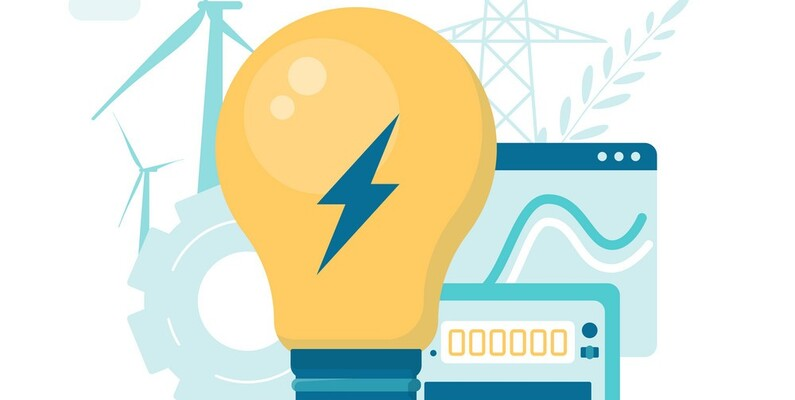

Este conjunto de datos está diseñado para predecir el consumo energético en función de diversas características del edificio y factores ambientales. Contiene datos sobre diversos tipos de edificios, superficie, número de ocupantes, electrodomésticos utilizados, temperatura media y día de la semana. El objetivo es crear un modelo predictivo para estimar el consumo energético utilizando estos atributos.

Kaggle Link: https://www.kaggle.com/datasets/govindaramsriram/energy-consumption-dataset-linear-regression

---

El Dataset viene dividido en 2 archivos train y test, sin embargo, nosotros uniremos estos 2 archivos en uno donde esten todos esos registros juntos y lo dividiremos nosotros mismos de la mejor forma

In [ ]:
import pandas as pd

train_inicial = pd.read_csv("/content/train_energy_data.csv")
test_inicial = pd.read_csv("/content/test_energy_data.csv")

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
train_inicial

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17
...,...,...,...,...,...,...,...
995,Residential,14419,68,44,23.95,Weekend,3661.21
996,Industrial,12194,7,22,14.67,Weekend,3546.34
997,Commercial,39562,88,20,32.18,Weekday,5147.21
998,Residential,8348,67,37,16.48,Weekend,3244.98


In [ ]:
test_inicial

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,24563,15,4,28.52,Weekday,2865.57
1,Commercial,27583,56,23,23.07,Weekend,4283.80
2,Commercial,45313,4,44,33.56,Weekday,5067.83
3,Residential,41625,84,17,27.39,Weekend,4624.30
4,Residential,36720,58,47,17.08,Weekday,4820.59
...,...,...,...,...,...,...,...
95,Commercial,1161,81,11,15.45,Weekend,3010.81
96,Residential,37943,50,23,21.73,Weekend,4248.49
97,Commercial,1558,27,29,16.86,Weekend,2843.60
98,Industrial,2145,56,12,11.77,Weekend,3348.39


Aqui los unimos

In [ ]:
data = pd.concat([train_inicial, test_inicial], ignore_index=True)
data

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17
...,...,...,...,...,...,...,...
1095,Commercial,1161,81,11,15.45,Weekend,3010.81
1096,Residential,37943,50,23,21.73,Weekend,4248.49
1097,Commercial,1558,27,29,16.86,Weekend,2843.60
1098,Industrial,2145,56,12,11.77,Weekend,3348.39



## Descripción de las Variables del Dataset

Este conjunto de datos contiene información sobre características de edificios y factores ambientales con el objetivo de **predecir el consumo energético**.

| Variable | Descripción |
|--------|-------------|
| **Building Type** | Tipo de edificio. Indica la categoría del inmueble, como residencial, comercial o industrial. |
| **Square Footage** | Superficie total del edificio medida en pies cuadrados. Representa el tamaño del edificio, lo cual puede influir en el consumo energético. |
| **Number of Occupants** | Número de personas que ocupan el edificio. Un mayor número de ocupantes suele incrementar el consumo de energía. |
| **Appliances Used** | Cantidad de electrodomésticos o equipos eléctricos utilizados dentro del edificio. |
| **Average Temperature** | Temperatura promedio registrada. Puede afectar el consumo energético debido al uso de sistemas de climatización. |
| **Day of Week** | Día de la semana en el que se registraron los datos. Permite analizar diferencias entre días laborales y fines de semana. |
| **Energy Consumption** | Consumo total de energía del edificio. Esta es la **variable objetivo (target)** que se busca predecir mediante el modelo de regresión. |

## Exploracion de los Datos

### Features

In [ ]:
data.columns

Index(['Building Type', 'Square Footage', 'Number of Occupants',
       'Appliances Used', 'Average Temperature', 'Day of Week',
       'Energy Consumption'],
      dtype='object')

### Nulos?

In [ ]:
data.isnull().sum()

,0
Building Type,0
Square Footage,0
Number of Occupants,0
Appliances Used,0
Average Temperature,0
Day of Week,0
Energy Consumption,0


No tenemos nulo por lo que podemos saltarnos la parte de imputacion de NaNs y demas

 ### Data Types

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        1100 non-null   object 
 1   Square Footage       1100 non-null   int64  
 2   Number of Occupants  1100 non-null   int64  
 3   Appliances Used      1100 non-null   int64  
 4   Average Temperature  1100 non-null   float64
 5   Day of Week          1100 non-null   object 
 6   Energy Consumption   1100 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 60.3+ KB


### Categoricas

Vemos que tenemos variables numericas y 2 categoricas o de tipo object, veamos que tienen o de que tipo son estas variables **categoricas**

In [ ]:
data[["Building Type","Day of Week"]]

,Building Type,Day of Week
0,Residential,Weekday
1,Commercial,Weekday
2,Industrial,Weekend
3,Residential,Weekday
4,Commercial,Weekday
...,...,...
1095,Commercial,Weekend
1096,Residential,Weekend
1097,Commercial,Weekend
1098,Industrial,Weekend


In [ ]:
data["Building Type"].unique()

array(['Residential', 'Commercial', 'Industrial'], dtype=object)

In [ ]:
data["Day of Week"].unique()

array(['Weekday', 'Weekend'], dtype=object)

- La variable **Building Type** o Tipo de Construccion es una variable categorica que tiene 3 posibles valores [Residencial,Comercial,Industrial], por lo que, esto nos abre diferentes puertas de analisis, puede ser que le hagamos un preprocesamiento de variables categoricas posteriormente con algo como **One-Hot Enconding** o alguna otra tecnica

- La variable **Day of Week** o Dia de la semana tambien es una variable categorica que tiene 2 posibles valores [Dia de Semana,Fin de semana], por lo que recae en lo mismo que la anterior

Ya veremos que tipos de analisis haremos con ellas o como las llevaremos, algunos de los posibles analisis son:

1. Construir un modelo para cada tipo de construccion
2. Preprocesar la variable categorica con ago como One-Hot encoding o basicamente vectorizarla y Crear modelos teniendola de esa forma


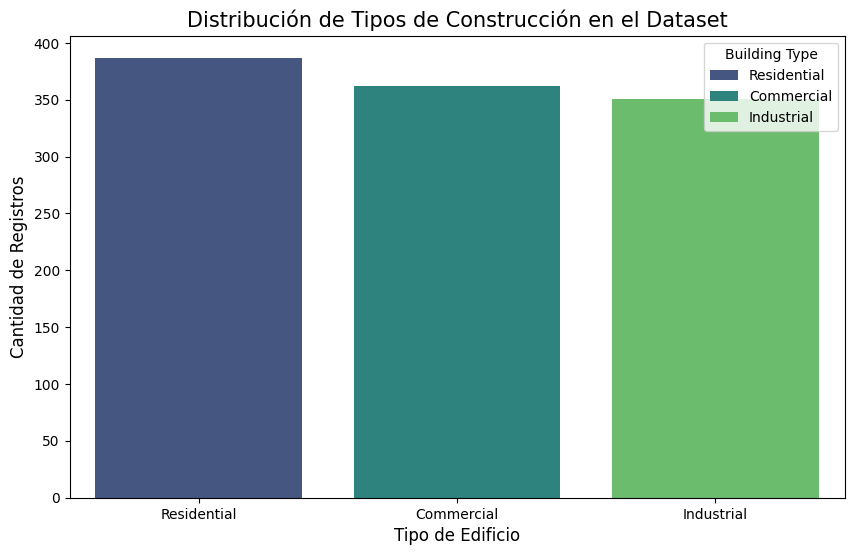

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 6))

# Creamos el gráfico de conteo
ax = sns.countplot(x='Building Type', data=data, palette='viridis', hue='Building Type', legend=True)

# Añadimos títulos y etiquetas claras
plt.title('Distribución de Tipos de Construcción en el Dataset', fontsize=15)
plt.xlabel('Tipo de Edificio', fontsize=12)
plt.ylabel('Cantidad de Registros', fontsize=12)

plt.show()

### Numericas

Hay que tener en cuenta que la variable a predecir será precisamente **Energy Consumption**

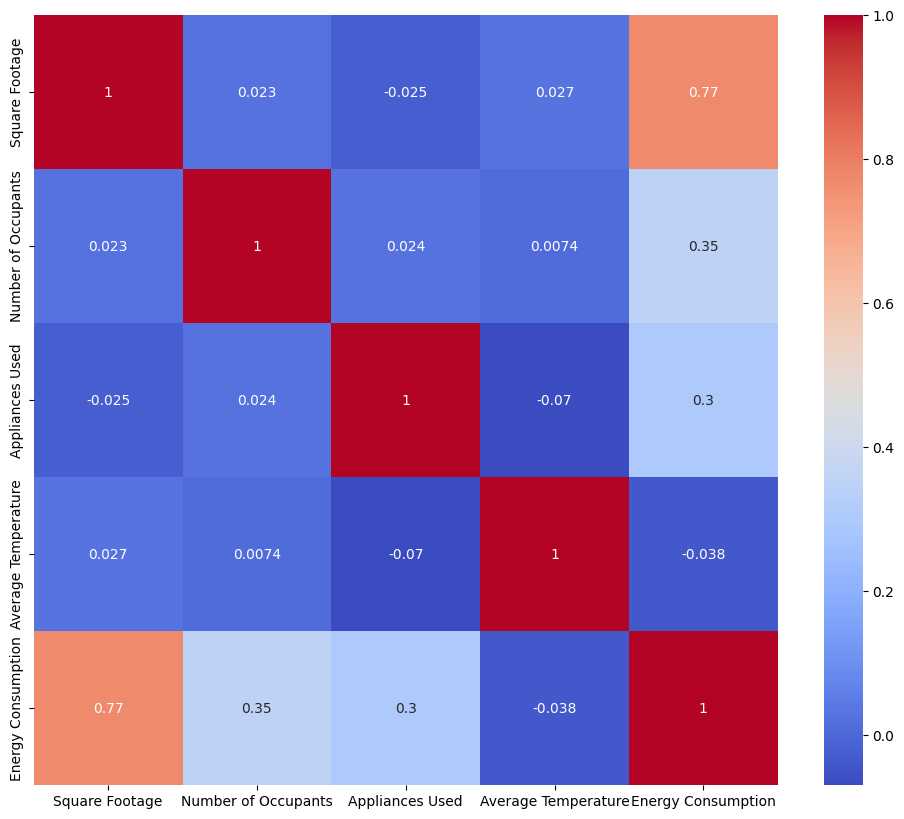

In [ ]:
corr = data.corr(numeric_only=True)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.show()

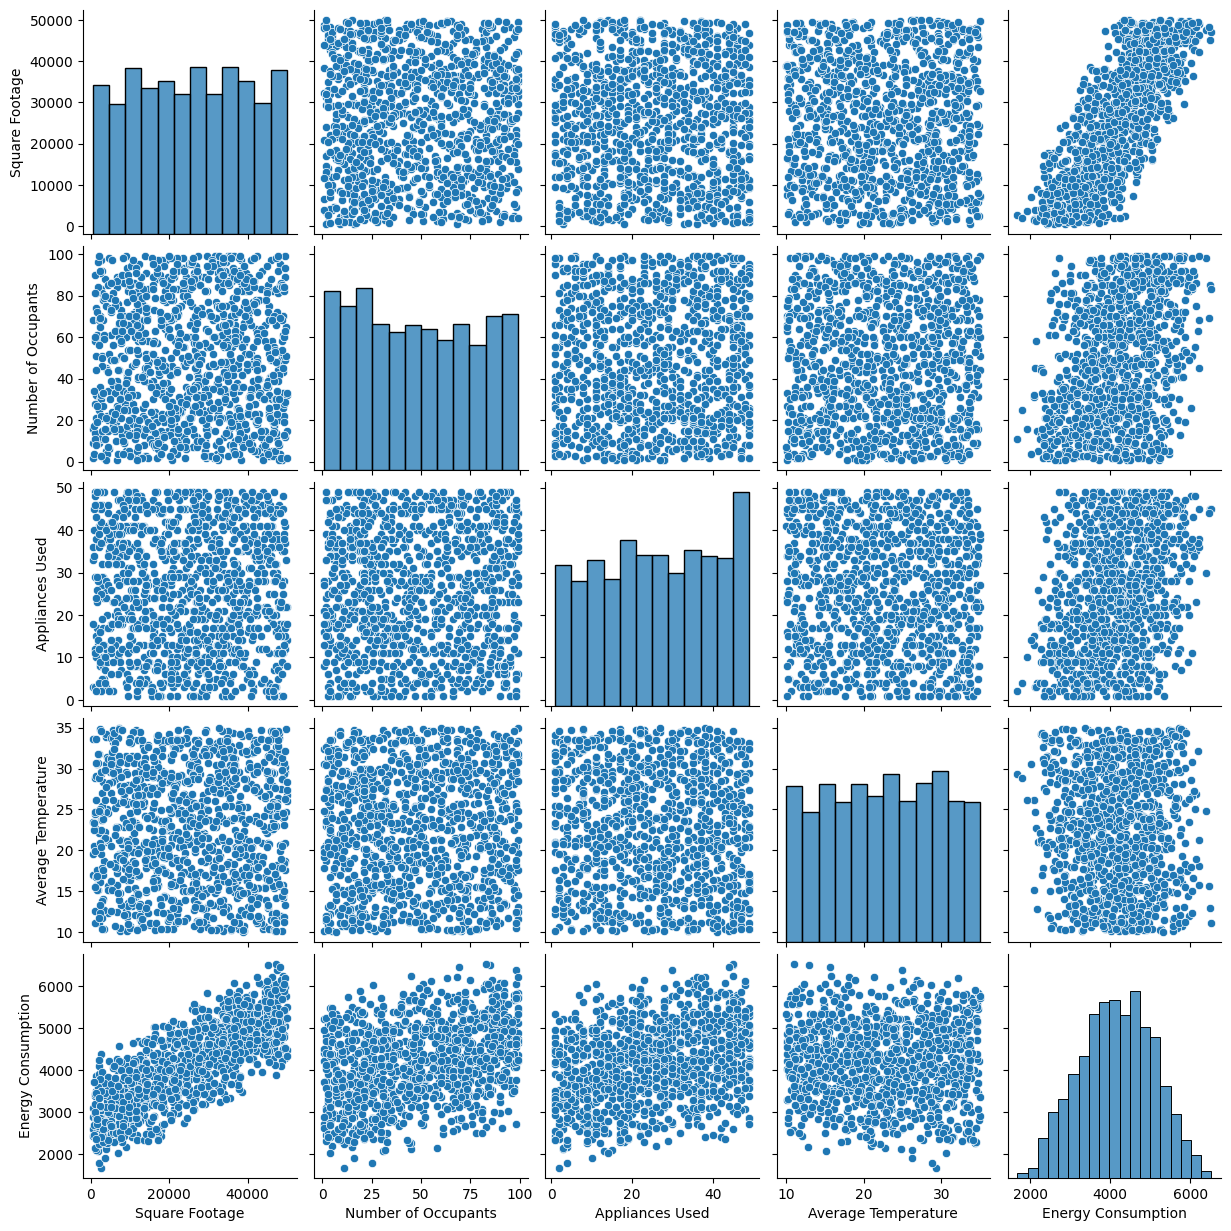

In [ ]:
sns.pairplot(data)

Vemos una muy alta correlacion entre **Square Footage** y nuestra variable a predecir y las relaciones con las demas son relaciones un poco debiles no son tan buenas, sin embargo, veamos que hacemos despues con el modelo

In [ ]:
data.describe()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
count,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000
mean,25500.527273,48.268182,25.730000,22.559745,4168.191273
std,14236.955632,29.127624,14.116209,7.122357,924.278723
min,560.000000,1.000000,1.000000,10.050000,1683.950000
25%,13203.750000,22.000000,13.000000,16.365000,3510.460000
50%,25785.500000,47.000000,26.000000,22.810000,4189.690000
75%,37536.750000,73.000000,38.000000,28.760000,4859.510000
max,49997.000000,99.000000,49.000000,34.990000,6530.600000


Vemos aqui que los datos en medidas descriptivas como la media, y la desviacion **varia muchisimo de Feature a Feature** lo que nos da un indicio de que para mejorar resultados tendremos que aplicar algun metodo de **Escalamiento** de los datos como **StandardScaler** o **MinMax**

## Preprocesamiento Estandar

Aqui ya lo ideal es que como ya conocemos o tenemos una mejor idea de nustros datos, ahora si veamos que cosas tenemos que mejorar aplicando **Pipelines** de procesamiento de los datos y cosas que se podrian mejorar para que al probar nuestros **Modelos** de ML sean buenisimos

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
numeric_features = [
    'Square Footage',
    'Number of Occupants',
    'Appliances Used',
    'Average Temperature'
]

categorical_features = [
    'Building Type',
    'Day of Week'
]

### Pipelines

In [ ]:
numeric_transformer = Pipeline(
    steps=[
        ("scaler",StandardScaler())
    ]
)

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

### ColumnTransformer

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num",numeric_transformer,numeric_features),
        ("cat",categorical_transformer,categorical_features)
    ]
)

### Division

In [ ]:
y = data['Energy Consumption']
X = data.drop(columns=['Energy Consumption'])

Usamos una division de:
- 70% Train
- 15% Validacion
- 15% Test

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=X['Building Type'] # <--- Clave aquí
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=X_temp['Building Type'] # <--- Clave aquí también
)

### Aplicacion del ColumnTransformer

Usamos .fit_transform() en el entrenamiento y solo .transform() en validación y prueba.

Ya si usaramos .fit() en el test, estariamos dándole al modelo información del futuro que no debería tener.

In [ ]:
X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)

In [ ]:
column_names = preprocessor.get_feature_names_out()

# Convertir las matrices de nuevo a DataFrames de Pandas
X_train_final = pd.DataFrame(X_train_prep, columns=column_names)
X_val_final = pd.DataFrame(X_val_prep, columns=column_names)
X_test_final = pd.DataFrame(X_test_prep, columns=column_names)

In [ ]:
X_train_final

,num__Square Footage,num__Number of Occupants,num__Appliances Used,num__Average Temperature,cat__Building Type_Commercial,cat__Building Type_Industrial,cat__Building Type_Residential,cat__Day of Week_Weekday,cat__Day of Week_Weekend
0,-1.064424,-0.089624,1.070398,-1.308967,1.0,0.0,0.0,1.0,0.0
1,-1.241624,-1.341202,0.788111,0.507115,0.0,0.0,1.0,1.0,0.0
2,-0.862530,-0.228688,-0.199892,0.501453,0.0,0.0,1.0,0.0,1.0
3,-1.333355,-0.437285,-1.399610,-1.071163,0.0,1.0,0.0,0.0,1.0
4,0.931746,-1.097839,0.646968,1.649421,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...
765,-0.321891,-0.993541,1.140969,0.410862,1.0,0.0,0.0,0.0,1.0
766,-0.073598,-1.097839,-1.046752,-1.504305,1.0,0.0,0.0,1.0,0.0
767,-1.036385,0.675229,1.070398,-0.211957,1.0,0.0,0.0,0.0,1.0
768,-0.818336,0.849059,0.011823,-1.051346,0.0,1.0,0.0,1.0,0.0


### 2do Aproach del dataset division del **tipo de construccion**


Aqui probamos otra division del problema, el otro enfoque es dividiendo el dataset por tipo de construccion y creamos modelos pro cada tipo

In [ ]:
data_para_div = data.drop(columns='Day of Week')

In [ ]:
def make_division(X,y):
  X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42)

  X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42)

  return X_train, X_test, X_val, y_train, y_test, y_val

##### Residencial

In [ ]:
data_residential = data_para_div[data_para_div["Building Type"]=="Residential"]
data_residential.drop(columns="Building Type",inplace=True)

/tmp/ipykernel_619/1604556317.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_residential.drop(columns="Building Type",inplace=True)


In [ ]:
data_residential

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
0,7063,76,10,29.84,2713.95
3,13265,14,41,32.82,3009.14
7,34950,60,18,28.24,4116.32
9,17467,42,36,28.84,3419.13
12,19139,97,34,17.35,4070.21
...,...,...,...,...,...
1090,31178,26,11,27.46,3451.58
1091,33642,66,11,16.89,3977.63
1092,34160,66,2,25.46,3830.68
1096,37943,50,23,21.73,4248.49


In [ ]:
X_residencial = data_residential.drop(columns="Energy Consumption")
y_residencial = data_residential["Energy Consumption"]

In [ ]:
X_train_resid, X_test_resid, X_val_resid, y_train_resid, y_test_resid, y_val_resid = make_division(X_residencial,y_residencial)

##### Comercial

In [ ]:
data_commercial = data_para_div[data_para_div["Building Type"]=="Commercial"]
data_commercial.drop(columns="Building Type",inplace=True)

/tmp/ipykernel_619/399799254.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_commercial.drop(columns="Building Type",inplace=True)


In [ ]:
X_commercial = data_commercial.drop(columns=['Energy Consumption'])
y_commercial = data_commercial["Energy Consumption"]

In [ ]:
X_train_commerc, X_test_commerc, X_val_commerc, y_train_commerc, y_test_commerc, y_val_commerc = make_division(X_commercial,y_commercial)

##### Industrial

In [ ]:
data_Industrial = data_para_div[data_para_div["Building Type"]=="Industrial"]
data_Industrial.drop(columns="Building Type",inplace=True)

/tmp/ipykernel_619/2728790753.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_Industrial.drop(columns="Building Type",inplace=True)


In [ ]:
X_industrial = data_Industrial.drop(columns=['Energy Consumption'])
y_industrial = data_Industrial["Energy Consumption"]

In [ ]:
X_train_industrial, X_test_industrial, X_val_industrial, y_train_industrial, y_test_industrial, y_val_industrial = make_division(X_commercial,y_commercial)

#### Escalado

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_residencial = StandardScaler()
scaler_comercial = StandardScaler()
scaler_industrial = StandardScaler()

##### Residencial Escalado

In [ ]:
X_train_resid_scaled = pd.DataFrame(scaler_residencial.fit_transform(X_train_resid), columns=X_train_resid.columns)
X_test_resid_scaled = pd.DataFrame(scaler_residencial.transform(X_test_resid), columns=X_test_resid.columns)
X_val_resid_scaled = pd.DataFrame(scaler_residencial.transform(X_val_resid), columns=X_val_resid.columns)

##### Comercial Escalado

In [ ]:
X_train_comer_scaled = pd.DataFrame(scaler_comercial.fit_transform(X_train_commerc), columns=X_train_resid.columns)
X_test_comer_scaled = pd.DataFrame(scaler_comercial.transform(X_test_commerc), columns=X_test_resid.columns)
X_val_comer_scaled = pd.DataFrame(scaler_comercial.transform(X_val_commerc), columns=X_val_resid.columns)

##### Industrial Escalado

In [ ]:
X_train_industrial_scaled = pd.DataFrame(scaler_industrial.fit_transform(X_train_industrial), columns=X_train_resid.columns)
X_test_industrial_scaled = pd.DataFrame(scaler_industrial.transform(X_test_industrial), columns=X_test_resid.columns)
X_val_industrial_scaled = pd.DataFrame(scaler_industrial.transform(X_val_industrial), columns=X_val_resid.columns)

In [ ]:
X_train_industrial_scaled

,Square Footage,Number of Occupants,Appliances Used,Average Temperature
0,0.287944,-1.458085,0.625552,-0.349201
1,0.561113,1.558260,-1.294598,0.678495
2,0.161488,-0.279284,1.142516,-0.977710
3,-1.699211,-1.492756,0.625552,0.038662
4,1.646474,-1.492756,-0.556079,0.309034
...,...,...,...,...
248,-0.025595,1.350236,-0.112967,0.324605
249,-0.814718,1.246224,0.403996,-1.643023
250,-1.568534,-0.903355,-0.039115,0.042909
251,1.465088,0.102093,1.437924,0.459084


In [ ]:
y_train_industrial

,Energy Consumption
540,4132.91
801,4640.78
652,4495.21
844,2696.49
77,4745.47
...,...
232,4446.22
344,4114.70
809,2779.25
1039,5611.18


## Modelos (Enfoque 1)

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, median_absolute_error
import numpy as np
import pandas as pd

def evaluar_modelo(nombre, modelo, X, y):
    y_pred = modelo.predict(X)
    return {
        'Modelo': nombre,
        'R2': r2_score(y, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y, y_pred)),
        'MAE': mean_absolute_error(y, y_pred),
        'MedAE': median_absolute_error(y, y_pred)
    }

### Baseline

In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression

# 1. Baseline Ingenuo (Media)
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train_final, y_train)

# 2. OLS (Sin regularización)
ols = LinearRegression()
ols.fit(X_train_final, y_train)

LinearRegression()

In [ ]:
metricas_dummy = evaluar_modelo("Media(Baseline)",dummy,X_val_final,y_val)
metricas_ols = evaluar_modelo("OLS sin Reg(Baseline)",ols,X_val_final,y_val)

In [ ]:
lista_metricas = []
lista_metricas.append(metricas_dummy)
lista_metricas.append(metricas_ols)

In [ ]:
df_comparativo = pd.DataFrame(lista_metricas)
df_comparativo.set_index('Modelo', inplace=True)

In [ ]:
X_train_final.columns

Index(['num__Square Footage', 'num__Number of Occupants',
       'num__Appliances Used', 'num__Average Temperature',
       'cat__Building Type_Commercial', 'cat__Building Type_Industrial',
       'cat__Building Type_Residential', 'cat__Day of Week_Weekday',
       'cat__Day of Week_Weekend'],
      dtype='object')

<Axes: >

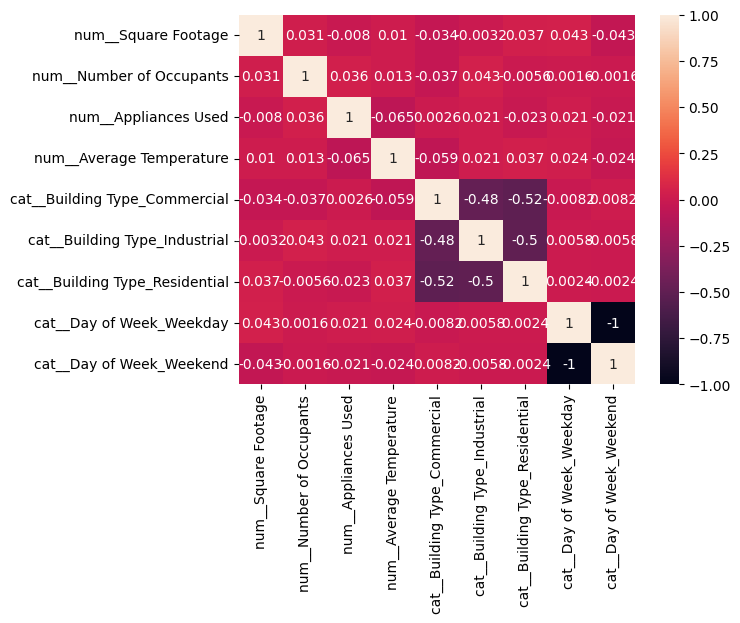

In [ ]:
corr1 = X_train_final.corr(numeric_only=True)
sns.heatmap(corr1,annot=True)

In [ ]:
df_comparativo

,R2,RMSE,MAE,MedAE
Modelo,,,,
Media(Baseline),-0.0007,941.635589,774.466942,714.681831
OLS sin Reg(Baseline),1.0000,0.013789,0.011663,0.010586


Esto de que el R2 nos de exacto en uno es un claro ejemplo de que tenemos variables que muy probablemente tienen colinealidad perfecta o data leakage
pero segun lo que vemos en el grafico de correlacion, se ve claramente, que es un tema de correlacion entre **cat__Day of Week_Weekday y cat__Day of Week_Weekend** teniendo una correlacion perfecta de **-1**, es decir, Son variables redundantes. Si no es fin de semana, por defecto es día de semana. Tener ambas en un modelo OLS puede causar inestabilidad numérica (aunque aquí el algoritmo lo resolvió).

---

En conclusion, para estos casos por ejemplo el OLS aunque dio un R2 muy alto, enrealidad no es confiable cosa que vemos que penalizara muchisimo **Lasso y Ridge** ya sea o bajando mucho su coeficiente o eliminando directamente y respectivamente. Y pues ElasticNet lo que hará es una combinacion de los 2

### Lasso

#### Lasso Regression

Lasso (Least Absolute Shrinkage and Selection Operator) es un modelo de regresión regularizado que introduce una penalización basada en el **valor absoluto de los coeficientes**.

A diferencia de Ridge, esta penalización puede hacer que algunos coeficientes se vuelvan exactamente cero, lo que permite realizar **selección automática de variables**.

Error + λ∑|β|

Esto significa que el modelo minimiza el error de predicción, pero añade una penalización proporcional al valor absoluto de los coeficientes.

El efecto principal de Lasso es:

- Reduce la magnitud de los coeficientes.
- Puede llevar algunos coeficientes exactamente a **cero**.
- Realiza una **selección automática de variables**, eliminando aquellas que aportan poca información al modelo.

Esto hace que Lasso produzca modelos más simples e interpretables, especialmente cuando existen muchas variables predictoras.

#### Hiperparámetro clave

**alpha:**  
Controla la fuerza de la penalización.

- Si **alpha = 0**, el modelo se convierte en una regresión lineal clásica.
- A medida que **alpha aumenta**, más coeficientes se reducen.
- Valores altos de alpha pueden llevar a que varias variables se eliminen del modelo.

El valor óptimo de alpha se determina normalmente mediante **validación cruzada**, evaluando qué nivel de regularización produce el mejor desempeño predictivo.

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np # Import numpy for np.sqrt

# Modelo base
lasso_model = Lasso(max_iter=10000)

# Espacio de búsqueda para alpha
param_distributions = {
    "alpha": uniform(0.0001, 10)
}

# Búsqueda de hiperparámetros
lasso_search = RandomizedSearchCV(
    lasso_model,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1
)

# Entrenamiento
lasso_search.fit(X_train_final, y_train)

# Mejor modelo
best_lasso = lasso_search.best_estimator_

# Predicción
y_pred_lasso = best_lasso.predict(X_val_final)

# Métricas
rmse_lasso = np.sqrt(mean_squared_error(y_val, y_pred_lasso)) # Corrected line
r2_lasso = r2_score(y_val, y_pred_lasso)

print("Best alpha:", lasso_search.best_params_)
print("RMSE:", rmse_lasso)
print("R2:", r2_lasso)

Best alpha: {'alpha': np.float64(0.20594494295802446)}
RMSE: 0.7453429596252562
R2: 0.9999993730247141


#### Interpretación de resultados — Lasso Regression

El modelo Lasso optimizado encontró un valor de **alpha ≈ 0.206**, lo que indica un nivel moderado de regularización aplicado a los coeficientes del modelo.

El valor de **RMSE = 0.7453** indica que el error promedio de predicción del modelo sobre el conjunto de validación es relativamente bajo, lo que sugiere una buena capacidad de ajuste a los datos.

Por otro lado, el **R² ≈ 0.999999** muestra que el modelo es capaz de explicar prácticamente toda la variabilidad de la variable objetivo *Energy Consumption*. Esto significa que las variables predictoras utilizadas contienen una gran cantidad de información relevante para explicar el consumo energético.

La regularización L1 aplicada por Lasso tiene la ventaja adicional de poder reducir algunos coeficientes a cero, lo que permite identificar qué variables aportan realmente al modelo y cuáles pueden ser descartadas. Esto contribuye a generar modelos más simples y potencialmente más interpretables.

En conjunto, los resultados indican que el modelo Lasso presenta un excelente desempeño predictivo en el conjunto de validación, manteniendo al mismo tiempo las ventajas de la regularización para controlar la complejidad del modelo.

### Ridge

#### Ridge Regression

Ridge es un modelo de regresión regularizado que introduce una penalización sobre el tamaño de los coeficientes del modelo. Su objetivo es evitar que los coeficientes crezcan demasiado cuando existe **multicolinealidad** entre las variables predictoras.

La idea principal es que el modelo no solo minimiza el error de predicción, sino que también penaliza coeficientes grandes.

Error + λ∑β²

Esto significa que el modelo busca minimizar el error, pero agregando un castigo proporcional al **cuadrado de los coeficientes**.

El efecto principal de Ridge es:

- Reduce la magnitud de los coeficientes.
- Hace el modelo más estable cuando hay variables correlacionadas.
- Mantiene **todas las variables dentro del modelo**, pero con coeficientes más pequeños.

A diferencia de Lasso, Ridge **no elimina variables**, sino que únicamente reduce su impacto en el modelo.

#### Hiperparámetro clave

**alpha:**  
Controla la fuerza de la penalización.

- Si **alpha = 0**, el modelo se convierte en una regresión lineal clásica (OLS).
- Valores más grandes de alpha aumentan la regularización, reduciendo más los coeficientes.

El valor óptimo de alpha suele encontrarse mediante **validación cruzada**, buscando el mejor equilibrio entre sesgo y varianza.

In [ ]:
# def make_ridge(X_train, y_train, X_val, y_val, lambda0, printing=True):

#     model = Ridge(alpha=float(lambda0))

#     r2_train, r2_val, mse_train, mse_val = fit_and_score(
#         model, X_train, y_train, X_val, y_val
#     )

#     if printing:
#         print(f"Model: Ridge(alpha={lambda0})")
#         print(f"R2 train = {r2_train:.6f} | val = {r2_val:.6f}")
#         print(f"MSE train = {mse_train:.6f} | val = {mse_val:.6f}")

#     return r2_train, r2_val, mse_train, mse_val

In [ ]:
from sklearn.linear_model import Ridge

# Modelo base
ridge_model = Ridge()

# Espacio de búsqueda
param_distributions = {
    "alpha": uniform(0.0001, 10)
}

# Búsqueda de hiperparámetros
ridge_search = RandomizedSearchCV(
    ridge_model,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1
)

# Entrenamiento
ridge_search.fit(X_train_final, y_train)

# Mejor modelo
best_ridge = ridge_search.best_estimator_

# Predicción
y_pred_ridge = best_ridge.predict(X_val_final)

# Métricas
rmse_ridge = np.sqrt(mean_squared_error(y_val, y_pred_ridge))
r2_ridge = r2_score(y_val, y_pred_ridge)

print("Best alpha:", ridge_search.best_params_)
print("RMSE:", rmse_ridge)
print("R2:", r2_ridge)

Best alpha: {'alpha': np.float64(0.20594494295802446)}
RMSE: 0.40369425545383975
R2: 0.9999998160739457


####Interpretación de resultados — Ridge Regression

El modelo Ridge optimizado encontró un valor de **alpha ≈ 0.206**, lo que indica el nivel de regularización aplicado al modelo. Este parámetro controla la penalización sobre los coeficientes, ayudando a reducir la magnitud de los mismos y a estabilizar el modelo cuando existen variables altamente correlacionadas.

El **RMSE = 0.4037** muestra que el error promedio de predicción del modelo sobre el conjunto de validación es bastante bajo, lo que indica una buena precisión en las predicciones del consumo energético.

Por otro lado, el **R² ≈ 0.9999998** indica que el modelo explica prácticamente toda la variabilidad de la variable objetivo *Energy Consumption*. Esto sugiere que las variables predictoras utilizadas contienen una fuerte relación con el consumo energético, permitiendo que el modelo capture casi completamente su comportamiento.

A diferencia de Lasso, Ridge no elimina variables del modelo, sino que reduce la magnitud de sus coeficientes. Esto permite conservar toda la información de los predictores mientras se controla el efecto de la multicolinealidad.

En general, los resultados muestran que Ridge logra un excelente desempeño predictivo, con un error bajo y una capacidad muy alta para explicar la variabilidad del consumo energético.


### ElasticNet

Es un modelo de regresión regularizado que combina las dos técnicas de penalización más populares: Lasso (L1) y Ridge (L2).

Imagina que Elastic Net es un "híbrido" que intenta obtener lo mejor de ambos mundos, resolviendo las limitaciones que cada uno tiene por separado.

$$Error + \lambda_1 \sum |\beta| + \lambda_2 \sum \beta^2$$

- Hiperparametros claves

1. alpha: Es la fuerza total de la penalización. Si es 0, es una regresión lineal normal.

2. l1_ratio: Es el "mezclador"

- Si l1_ratio = 1, el modelo es 100% Lasso.
- Si l1_ratio = 0, el modelo es 100% Ridge
- Un valor de 0.5 significa que aplica mitad y mitad de cada castigo.

3. selection: define la estrategia que utiliza el algoritmo para actualizar los coeficientes ($\beta$) durante el proceso de optimización (que en Elastic Net se hace mediante una técnica llamada Descenso de Coordenadas)

- selection='cyclic' (El predeterminado): En cada iteración, ajusta el coeficiente de la variable 1, luego el de la 2, y así hasta completar el ciclo. Es determinista (siempre da el mismo resultado con los mismos datos) y suele ser muy estable.

- selection='random': Utiliza una selección aleatoria para decidir qué peso ajustar en cada momento. Suele llevar a una convergencia más rápida, especialmente cuando tienes muchas variables o cuando estas están muy correlacionadas entre sí.

#### Train & Fine-tuning

In [ ]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

# Definir el modelo
en_model = ElasticNet(max_iter=10000) # Aumentamos iteraciones para asegurar convergencia

# Espacio de búsqueda continuo
param_distributions = {
    'alpha': uniform(0.001, 10.0),    # Prueba valores desde casi 0 hasta 10
    'l1_ratio': uniform(0.0, 1.0),    # Explora todo el espectro entre Ridge y Lasso
    'selection': ['cyclic', 'random'] # Método de actualización de coeficientes
}

# Configurar la búsqueda aleatoria
random_search_en = RandomizedSearchCV(
    estimator=en_model,
    param_distributions=param_distributions,
    n_iter=100,              # Probará 100 combinaciones aleatorias
    cv=5,                    # Validación cruzada de 5 pliegues
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Ajustar a los datos
random_search_en.fit(X_train_final, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(cv=5, estimator=ElasticNet(max_iter=10000), n_iter=100,
                   n_jobs=-1,
                   param_distributions={'alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7cd9cda42a80>,
                                        'l1_ratio': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7cd9cd222420>,
                                        'selection': ['cyclic', 'random']},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=1)

#### Best Model

In [ ]:
best_en_model = random_search_en.best_estimator_
print("--- Mejores Parámetros Encontrados ---")
print(f"Alpha: {random_search_en.best_params_['alpha']:.4f}")
print(f"L1_ratio: {random_search_en.best_params_['l1_ratio']:.4f}")
print(f"Selección: {random_search_en.best_params_['selection']}")

--- Mejores Parámetros Encontrados ---
Alpha: 0.2068
L1_ratio: 0.9699
Selección: random


#### Metricas y Comparativa

In [ ]:
metricas_lasso = evaluar_modelo("Lasso Optimizado", best_lasso, X_val_final, y_val)
metricas_ridge = evaluar_modelo("Ridge Optimizado", best_ridge, X_val_final, y_val)
metricas_en_optimo = evaluar_modelo("ElasticNet Optimizado", best_en_model, X_val_final, y_val)

# Clear previous metrics to avoid duplicates
lista_metricas = []

lista_metricas.append(metricas_dummy)
lista_metricas.append(metricas_ols)
lista_metricas.append(metricas_lasso)
lista_metricas.append(metricas_ridge)
lista_metricas.append(metricas_en_optimo)

df_comparativo = pd.DataFrame(lista_metricas).set_index('Modelo')
df_comparativo

,R2,RMSE,MAE,MedAE
Modelo,,,,
Media(Baseline),-0.000700,941.635589,774.466942,714.681831
OLS sin Reg(Baseline),1.000000,0.013789,0.011663,0.010586
Lasso Optimizado,0.999999,0.745343,0.615178,0.557587
Ridge Optimizado,1.000000,0.403694,0.338389,0.292599
ElasticNet Optimizado,0.999892,9.789958,8.195974,6.962158


### Comparación de Modelos

La tabla comparativa ofrece una clara visión general del rendimiento de cada modelo en el conjunto de validación:

*   **Media (Baseline)**: Como era de esperar, este modelo de línea base simple tuvo un rendimiento deficiente, con un R2 cercano a 0 y altas métricas de error (RMSE, MAE, MedAE). Esto indica que los modelos más complejos están aprendiendo algo útil.

*   **OLS sin Reg (Baseline)**: Este modelo muestra un R2 de 1.0 y métricas de error extremadamente bajas. Si bien un R2 perfecto puede parecer ideal, sugiere fuertemente un problema como la **colinealidad perfecta** en sus características. Como discutimos anteriormente, las variables 'cat__Day of Week_Weekday' y 'cat__Day of Week_Weekend' codificadas en one-hot están perfectamente correlacionadas negativamente (si una es 1, la otra es 0), lo que puede causar inestabilidad numérica y resultados engañosamente perfectos en OLS.

*   **Lasso Optimizado**: Este modelo también logró un R2 muy cercano a 1.0 (0.999999) y métricas de error muy bajas. La fortaleza de Lasso es su capacidad para realizar la selección de características llevando los coeficientes de las características menos importantes o altamente correlacionadas a cero. En este caso, probablemente mitigó el problema de multicolinealidad, lo que llevó a un ajuste muy robusto.

*   **Ridge Optimizado**: De manera similar a Lasso, Ridge también logró un R2 de 1.0 y métricas de error muy bajas. Ridge maneja la multicolinealidad reduciendo los coeficientes de las características correlacionadas entre sí, en lugar de eliminarlas por completo. Obtuvo un rendimiento ligeramente mejor que Lasso en términos de RMSE, MAE y MedAE.

*   **ElasticNet Optimizado**: Este modelo, que combina la regularización L1 (Lasso) y L2 (Ridge), muestra un R2 muy alto (0.999892) pero métricas de error ligeramente más altas en comparación con los modelos Lasso y Ridge individuales, y significativamente más altas que OLS. Esto es interesante; podría indicar que la combinación específica de penalización L1 y L2 encontrada por `RandomizedSearchCV` no fue tan efectiva como la L1 o L2 pura para esta estructura de datos particular, o quizás el espacio de búsqueda no encontró el equilibrio óptimo para ElasticNet dada la colinealidad extrema.

**En resumen**: Todos los modelos lineales con o sin regularización (excepto la línea base media ingenua) están funcionando excepcionalmente bien, con puntuaciones R2 extremadamente cercanas a 1.0. Este rendimiento excepcional, particularmente el R2 perfecto de OLS y Ridge, refuerza la sospecha de colinealidad perfecta. Si bien Lasso y Ridge están diseñados para manejar tales problemas, sus puntuaciones casi perfectas sugieren que el modelo podría ser demasiado bueno para ser verdad, o ha aprendido perfectamente la relación en los datos de entrenamiento, lo que podría o no generalizarse perfectamente a datos no vistos si la colinealidad conduce a un sobreajuste al conjunto de entrenamiento específico.

Dados estos resultados, el modelo **Ridge Optimizado** parece tener el mejor rendimiento con el RMSE, MAE y MedAE más bajos entre los modelos regularizados, al tiempo que muestra un R2 robusto. Sin embargo, vale la pena reevaluar la multicolinealidad y potencialmente eliminar una de las características altamente correlacionadas si el R2 perfecto sigue siendo un problema en otros contextos.

#### Convergencia Hiperparametros

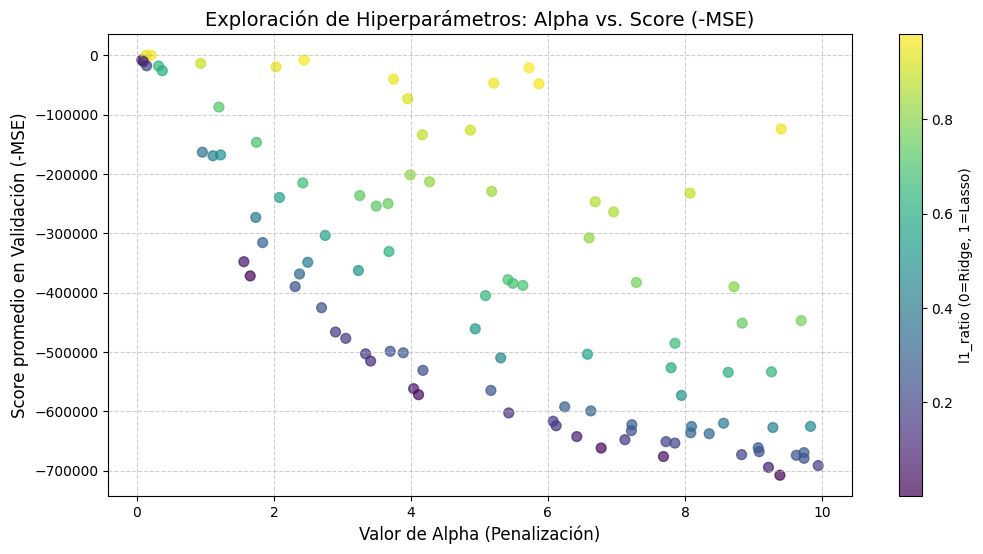

In [ ]:
results_df = pd.DataFrame(random_search_en.cv_results_)

plt.figure(figsize=(12, 6))
scatter = plt.scatter(results_df['param_alpha'],
                      results_df['mean_test_score'],
                      c=results_df['param_l1_ratio'],
                      cmap='viridis',
                      alpha=0.7,
                      s=50)

plt.colorbar(scatter, label='l1_ratio (0=Ridge, 1=Lasso)')

plt.title('Exploración de Hiperparámetros: Alpha vs. Score (-MSE)', fontsize=14)
plt.xlabel('Valor de Alpha (Penalización)', fontsize=12)
plt.ylabel('Score promedio en Validación (-MSE)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

#### **2do Aproach con el Dataset Dividido por tipo de Construccion**

Ahora realizaremos los modelos en base al **Tipo de Construccion**

## Modelos (Enfoque 2)

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

### Residenciales

##### Lasso

In [ ]:
# Modelo base Lasso
lasso_model_resid = Lasso(max_iter=10000)

# Espacio de búsqueda para alpha
param_distributions_lasso = {
    "alpha": uniform(0.0001, 10)
}

# Búsqueda aleatoria de hiperparámetros
random_search_lasso_resid = RandomizedSearchCV(
    estimator=lasso_model_resid,
    param_distributions=param_distributions_lasso,
    n_iter=100,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Entrenamiento
random_search_lasso_resid.fit(X_train_resid_scaled, y_train_resid)

# Mejor modelo encontrado
best_lasso_resid = random_search_lasso_resid.best_estimator_

print("--- Mejores parámetros Lasso Residencial ---")
print(random_search_lasso_resid.best_params_)

# Métricas en validación
metricas_lasso_resid = evaluar_modelo(
    "Lasso Residencial",
    best_lasso_resid,
    X_val_resid_scaled,
    y_val_resid
)

metricas_lasso_resid

Fitting 5 folds for each of 100 candidates, totalling 500 fits
--- Mejores parámetros Lasso Residencial ---
{'alpha': np.float64(0.055321171236023994)}


{'Modelo': 'Lasso Residencial',
 'R2': 0.9989645512432468,
 'RMSE': np.float64(25.292742587390947),
 'MAE': 25.139270245387863,
 'MedAE': np.float64(24.854306853065737)}

##### Ridge

In [ ]:
# Modelo base Ridge
ridge_model_resid = Ridge()

# Espacio de búsqueda para alpha
param_distributions_ridge = {
    "alpha": uniform(0.0001, 10)
}

# Búsqueda aleatoria de hiperparámetros
random_search_ridge_resid = RandomizedSearchCV(
    estimator=ridge_model_resid,
    param_distributions=param_distributions_ridge,
    n_iter=100,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Entrenamiento
random_search_ridge_resid.fit(X_train_resid_scaled, y_train_resid)

# Mejor modelo encontrado
best_ridge_resid = random_search_ridge_resid.best_estimator_

print("--- Mejores parámetros Ridge Residencial ---")
print(random_search_ridge_resid.best_params_)

# Métricas en validación
metricas_ridge_resid = evaluar_modelo(
    "Ridge Residencial",
    best_ridge_resid,
    X_val_resid_scaled,
    y_val_resid
)

metricas_ridge_resid

Fitting 5 folds for each of 100 candidates, totalling 500 fits
--- Mejores parámetros Ridge Residencial ---
{'alpha': np.float64(0.055321171236023994)}


{'Modelo': 'Ridge Residencial',
 'R2': 0.9989653667237617,
 'RMSE': np.float64(25.282780819014665),
 'MAE': 25.135544635477086,
 'MedAE': np.float64(24.81307327629247)}

##### ElasticNet

In [ ]:
# Definir el modelo
en_model = ElasticNet(max_iter=10000) # Aumentamos iteraciones para asegurar convergencia

# Espacio de búsqueda continuo
param_distributions = {
    'alpha': uniform(0.001, 10.0),    # Prueba valores desde casi 0 hasta 10
    'l1_ratio': uniform(0.0, 1.0),    # Explora todo el espectro entre Ridge y Lasso
    'selection': ['cyclic', 'random'] # Método de actualización de coeficientes
}

# Configurar la búsqueda aleatoria
random_search_en = RandomizedSearchCV(
    estimator=en_model,
    param_distributions=param_distributions,
    n_iter=100,              # Probará 100 combinaciones aleatorias
    cv=5,                    # Validación cruzada de 5 pliegues
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Ajustar a los datos
random_search_en.fit(X_train_resid_scaled, y_train_resid)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(cv=5, estimator=ElasticNet(max_iter=10000), n_iter=100,
                   n_jobs=-1,
                   param_distributions={'alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7cd9ce116840>,
                                        'l1_ratio': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7cd9ce28cf50>,
                                        'selection': ['cyclic', 'random']},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=1)

In [ ]:
best_en_model = random_search_en.best_estimator_

metricas_elastic_resid = evaluar_modelo("ElasticNet Residencial", best_en_model, X_val_resid_scaled, y_val_resid)

##### Mejor Modelo Residencial

In [ ]:
metricas_residencial = []

metricas_residencial.append(metricas_lasso_resid)
metricas_residencial.append(metricas_ridge_resid)
metricas_residencial.append(metricas_elastic_resid)

metricas_resid_df = pd.DataFrame(metricas_residencial).set_index("Modelo")
metricas_resid_df = metricas_resid_df.sort_values(by=["R2", "RMSE"], ascending=[False, True])

metricas_resid_df

,R2,RMSE,MAE,MedAE
Modelo,,,,
Ridge Residencial,0.998965,25.282781,25.135545,24.813073
Lasso Residencial,0.998965,25.292743,25.139270,24.854307
ElasticNet Residencial,0.998932,25.683650,25.100117,25.309808


### Comercial

##### Lasso

In [ ]:
# Modelo base Lasso
lasso_model_commerc = Lasso(max_iter=10000)

# Espacio de búsqueda
param_distributions_lasso = {
    "alpha": uniform(0.0001, 10)
}

# Búsqueda aleatoria
random_search_lasso_commerc = RandomizedSearchCV(
    estimator=lasso_model_commerc,
    param_distributions=param_distributions_lasso,
    n_iter=100,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Entrenamiento
random_search_lasso_commerc.fit(X_train_comer_scaled, y_train_commerc)

# Mejor modelo
best_lasso_commerc = random_search_lasso_commerc.best_estimator_

print("--- Mejores parámetros Lasso Comercial ---")
print(random_search_lasso_commerc.best_params_)

# Métricas
metricas_lasso_commerc = evaluar_modelo(
    "Lasso Comercial",
    best_lasso_commerc,
    X_val_comer_scaled,
    y_val_commerc
)

metricas_lasso_commerc

Fitting 5 folds for each of 100 candidates, totalling 500 fits
--- Mejores parámetros Lasso Comercial ---
{'alpha': np.float64(0.055321171236023994)}


{'Modelo': 'Lasso Comercial',
 'R2': 0.9988161858017882,
 'RMSE': np.float64(25.35836083599191),
 'MAE': 24.98761872270233,
 'MedAE': np.float64(24.443446870602884)}

##### Ridge

In [ ]:
# Modelo base Ridge
ridge_model_commerc = Ridge()

# Espacio de búsqueda
param_distributions_ridge = {
    "alpha": uniform(0.0001, 10)
}

# Búsqueda aleatoria
random_search_ridge_commerc = RandomizedSearchCV(
    estimator=ridge_model_commerc,
    param_distributions=param_distributions_ridge,
    n_iter=100,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Entrenamiento
random_search_ridge_commerc.fit(X_train_comer_scaled, y_train_commerc)

# Mejor modelo
best_ridge_commerc = random_search_ridge_commerc.best_estimator_

print("--- Mejores parámetros Ridge Comercial ---")
print(random_search_ridge_commerc.best_params_)

# Métricas
metricas_ridge_commerc = evaluar_modelo(
    "Ridge Comercial",
    best_ridge_commerc,
    X_val_comer_scaled,
    y_val_commerc
)

metricas_ridge_commerc

Fitting 5 folds for each of 100 candidates, totalling 500 fits
--- Mejores parámetros Ridge Comercial ---
{'alpha': np.float64(0.055321171236023994)}


{'Modelo': 'Ridge Comercial',
 'R2': 0.9988156378824176,
 'RMSE': np.float64(25.364228619035643),
 'MAE': 24.989696467623727,
 'MedAE': np.float64(24.559248110061162)}

##### ElasticNet

In [ ]:
# Definir el modelo
en_model = ElasticNet(max_iter=10000) # Aumentamos iteraciones para asegurar convergencia

# Espacio de búsqueda continuo
param_distributions = {
    'alpha': uniform(0.001, 10.0),    # Prueba valores desde casi 0 hasta 10
    'l1_ratio': uniform(0.0, 1.0),    # Explora todo el espectro entre Ridge y Lasso
    'selection': ['cyclic', 'random'] # Método de actualización de coeficientes
}

# Configurar la búsqueda aleatoria
random_search_en = RandomizedSearchCV(
    estimator=en_model,
    param_distributions=param_distributions,
    n_iter=100,              # Probará 100 combinaciones aleatorias
    cv=5,                    # Validación cruzada de 5 pliegues
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Ajustar a los datos
random_search_en.fit(X_train_comer_scaled, y_train_commerc)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(cv=5, estimator=ElasticNet(max_iter=10000), n_iter=100,
                   n_jobs=-1,
                   param_distributions={'alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7cd9cde4cef0>,
                                        'l1_ratio': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7cd9cdfd53d0>,
                                        'selection': ['cyclic', 'random']},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=1)

In [ ]:
best_en_model = random_search_en.best_estimator_

metricas_elastic_commerc = evaluar_modelo("ElasticNet Comercial", best_en_model, X_val_comer_scaled, y_val_commerc)

##### Mejor Modelo Comerciales

In [ ]:
metricas_comerciales = []

metricas_comerciales.append(metricas_lasso_commerc)
metricas_comerciales.append(metricas_ridge_commerc)
metricas_comerciales.append(metricas_elastic_commerc)

metricas_comerciales_df = pd.DataFrame(metricas_comerciales).set_index("Modelo")
metricas_comerciales_df = metricas_comerciales_df.sort_values(by=["R2", "RMSE"], ascending=[False, True])

metricas_comerciales_df

,R2,RMSE,MAE,MedAE
Modelo,,,,
Lasso Comercial,0.998816,25.358361,24.987619,24.443447
Ridge Comercial,0.998816,25.364229,24.989696,24.559248
ElasticNet Comercial,0.998707,26.500403,25.461563,24.847082


### Industrial

##### Lasso

In [ ]:
# Modelo base Lasso
lasso_model_industrial = Lasso(max_iter=10000)

# Espacio de búsqueda
param_distributions_lasso = {
    "alpha": uniform(0.0001, 10)
}

# Búsqueda aleatoria
random_search_lasso_industrial = RandomizedSearchCV(
    estimator=lasso_model_industrial,
    param_distributions=param_distributions_lasso,
    n_iter=100,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Entrenamiento
random_search_lasso_industrial.fit(X_train_industrial_scaled, y_train_industrial)

# Mejor modelo
best_lasso_industrial = random_search_lasso_industrial.best_estimator_

print("--- Mejores parámetros Lasso Industrial ---")
print(random_search_lasso_industrial.best_params_)

# Métricas
metricas_lasso_industrial = evaluar_modelo(
    "Lasso Industrial",
    best_lasso_industrial,
    X_val_industrial_scaled,
    y_val_industrial
)

metricas_lasso_industrial

Fitting 5 folds for each of 100 candidates, totalling 500 fits
--- Mejores parámetros Lasso Industrial ---
{'alpha': np.float64(0.055321171236023994)}


{'Modelo': 'Lasso Industrial',
 'R2': 0.9988161858017882,
 'RMSE': np.float64(25.35836083599191),
 'MAE': 24.98761872270233,
 'MedAE': np.float64(24.443446870602884)}

##### Ridge

In [ ]:
# Modelo base Ridge
ridge_model_industrial = Ridge()

# Espacio de búsqueda
param_distributions_ridge = {
    "alpha": uniform(0.0001, 10)
}

# Búsqueda aleatoria
random_search_ridge_industrial = RandomizedSearchCV(
    estimator=ridge_model_industrial,
    param_distributions=param_distributions_ridge,
    n_iter=100,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Entrenamiento
random_search_ridge_industrial.fit(X_train_industrial_scaled, y_train_industrial)

# Mejor modelo
best_ridge_industrial = random_search_ridge_industrial.best_estimator_

print("--- Mejores parámetros Ridge Industrial ---")
print(random_search_ridge_industrial.best_params_)

# Métricas
metricas_ridge_industrial = evaluar_modelo(
    "Ridge Industrial",
    best_ridge_industrial,
    X_val_industrial_scaled,
    y_val_industrial
)

metricas_ridge_industrial

Fitting 5 folds for each of 100 candidates, totalling 500 fits
--- Mejores parámetros Ridge Industrial ---
{'alpha': np.float64(0.055321171236023994)}


{'Modelo': 'Ridge Industrial',
 'R2': 0.9988156378824176,
 'RMSE': np.float64(25.364228619035643),
 'MAE': 24.989696467623727,
 'MedAE': np.float64(24.559248110061162)}

##### ElasticNet

In [ ]:
# Definir el modelo
en_model = ElasticNet(max_iter=10000) # Aumentamos iteraciones para asegurar convergencia

# Espacio de búsqueda continuo
param_distributions = {
    'alpha': uniform(0.001, 10.0),    # Prueba valores desde casi 0 hasta 10
    'l1_ratio': uniform(0.0, 1.0),    # Explora todo el espectro entre Ridge y Lasso
    'selection': ['cyclic', 'random'] # Método de actualización de coeficientes
}

# Configurar la búsqueda aleatoria
random_search_en = RandomizedSearchCV(
    estimator=en_model,
    param_distributions=param_distributions,
    n_iter=100,              # Probará 100 combinaciones aleatorias
    cv=5,                    # Validación cruzada de 5 pliegues
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Ajustar a los datos
random_search_en.fit(X_train_industrial_scaled, y_train_industrial)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(cv=5, estimator=ElasticNet(max_iter=10000), n_iter=100,
                   n_jobs=-1,
                   param_distributions={'alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7cd9cd1e1d00>,
                                        'l1_ratio': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7cd9cda405f0>,
                                        'selection': ['cyclic', 'random']},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=1)

In [ ]:
best_en_model = random_search_en.best_estimator_

metricas_elastic_industrial = evaluar_modelo("ElasticNet Industrial", best_en_model, X_val_comer_scaled, y_val_commerc)

##### Mejor Modelo Industriales

In [ ]:
metricas_industriales = []

metricas_industriales.append(metricas_lasso_industrial)
metricas_industriales.append(metricas_ridge_industrial)
metricas_industriales.append(metricas_elastic_industrial)

metricas_industrial_df = pd.DataFrame(metricas_industriales).set_index("Modelo")
metricas_industrial_df = metricas_industrial_df.sort_values(by=["R2", "RMSE"], ascending=[False, True])

metricas_industrial_df

,R2,RMSE,MAE,MedAE
Modelo,,,,
Lasso Industrial,0.998816,25.358361,24.987619,24.443447
Ridge Industrial,0.998816,25.364229,24.989696,24.559248
ElasticNet Industrial,0.998707,26.500212,25.461008,24.846083


# Conclusion

1.

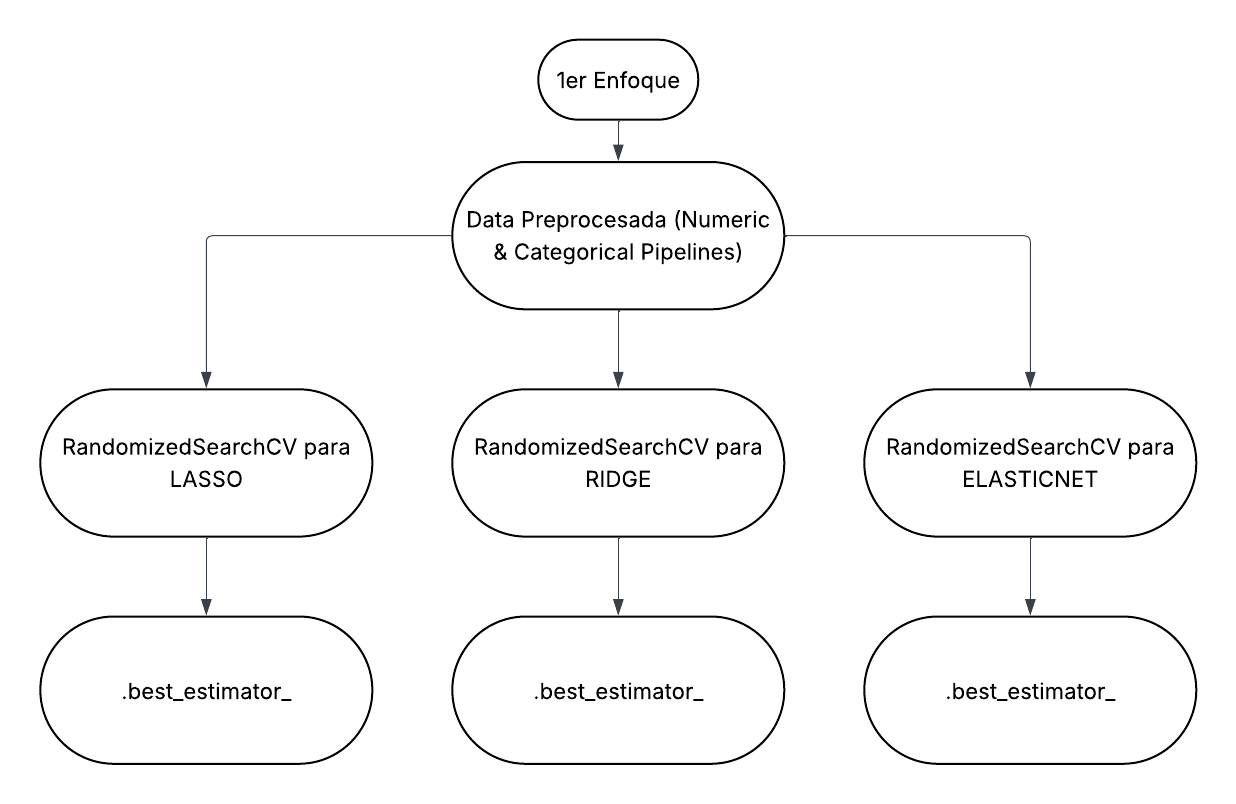

2. Hacer Zoom para ver el pipeline del enfoque #2

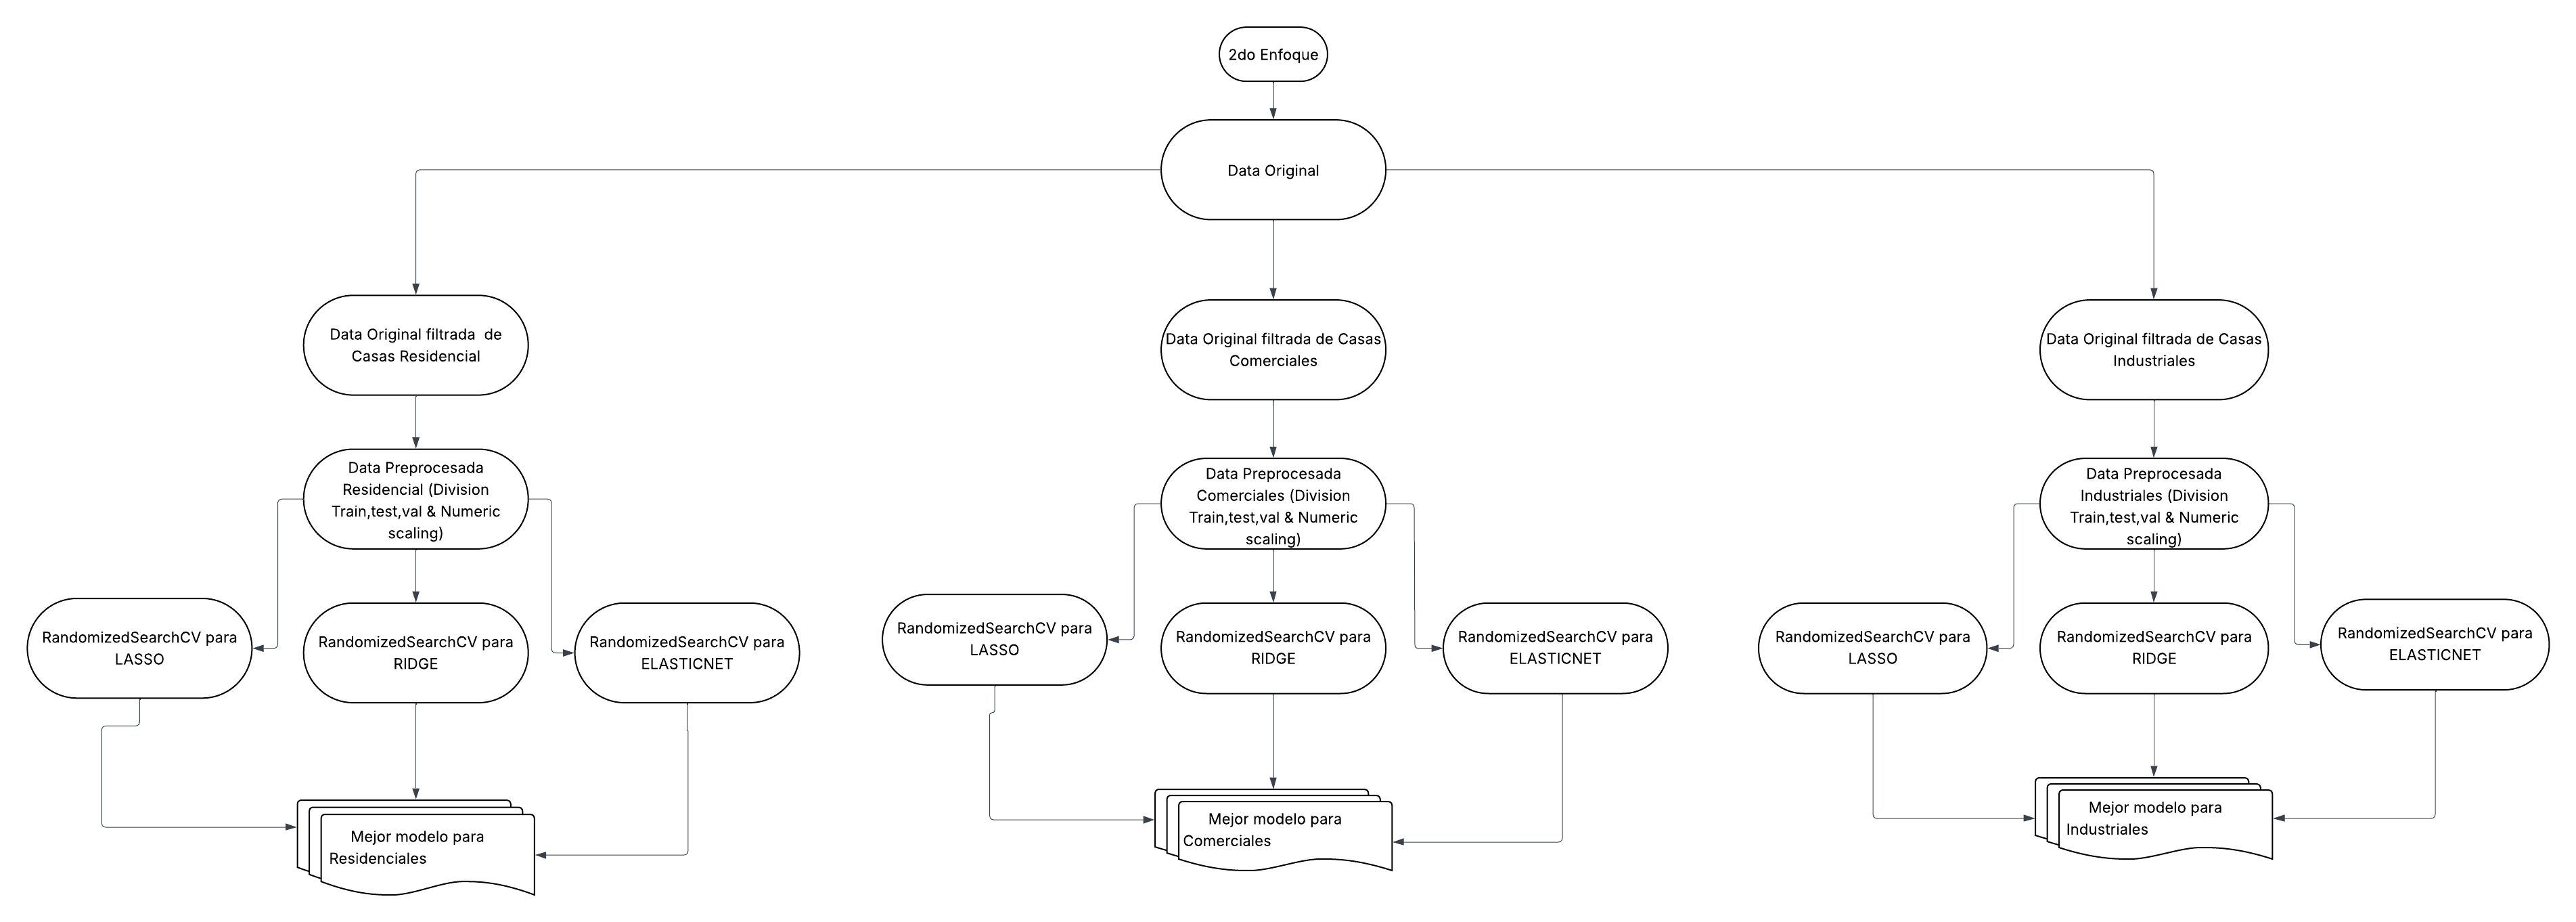

En conclusion, Los dos enfoques utilizados para predecir el consumo energético demostraron ser altamente efectivos. El primer enfoque permitió una visión general del conjunto de datos, mientras que el segundo enfoque sugirió que la creación de un pipeline automatizado, que seleccione el mejor modelo según el tipo específico de construcción, optimizaría significativamente el cálculo del consumo energético.

Se observó que el comportamiento del consumo varía según las características de la edificación. Por ello, automatizar el proceso para que el sistema identifique el modelo más preciso para cada tipo de construcción representa una oportunidad de mejora para futuros despliegues del modelo, permitiendo una estimación más personalizada y exacta.

# Para convertir a HTML

In [12]:
notebook_path_in_drive = '/content/drive/MyDrive/Taller-Ridge-Lasso/energy-consumption.ipynb'
!cp '{notebook_path_in_drive}' .

In [13]:
!jupyter nbconvert --to html energy-consumption.ipynb

[NbConvertApp] Converting notebook energy-consumption.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 2510715 bytes to energy-consumption.html
